In [16]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/nihitreddy/mlwc-assignment2-real1/RIS_Dataset.mat


In [17]:
import scipy.io as sio

mat = sio.loadmat('/kaggle/input/datasets/nihitreddy/mlwc-assignment2-real1/RIS_Dataset.mat')

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'DL_RIS_Y_pilot', 'DL_RIS_Y_data', 'DL_RIS_X_data', 'SNR_dB', 'SER_LS', 'SER_MMSE'])


TRAINING 

Running on cuda


Chunk 1/8


  0%|          | 0/100 [00:00<?, ?it/s]

Final -> Train: 0.00511, Val: 0.01489

Chunk 2/8


  0%|          | 0/100 [00:00<?, ?it/s]

Final -> Train: 0.00535, Val: 0.01551

Chunk 3/8


...

Final -> Train: 0.00619, Val: 0.01625

Chunk 7/8


  0%|          | 0/100 [00:00<?, ?it/s]

Final -> Train: 0.00465, Val: 0.01402

Chunk 8/8


  0%|          | 0/100 [00:00<?, ?it/s]

Final -> Train: 0.00441, Val: 0.01395


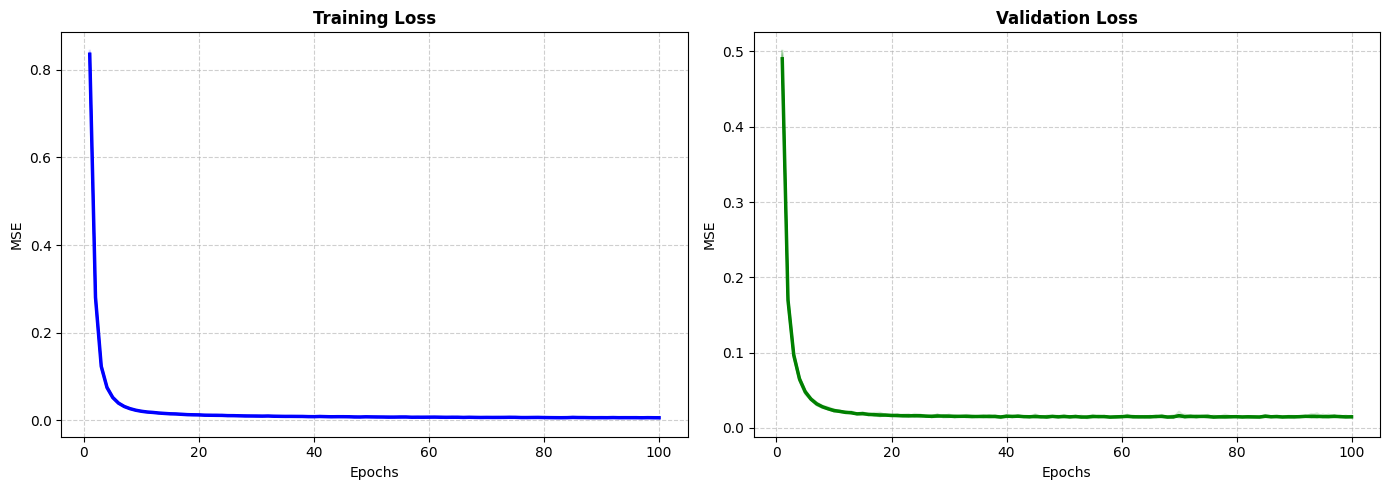

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm.auto import tqdm


# ----------------------------
# Model Definition
# ----------------------------
class RISNet(nn.Module):
    def __init__(self, in_features=256, out_features=16):
        super().__init__()
        self.blocks = nn.ModuleList([
            nn.Linear(in_features, 500),
            nn.Linear(500, 250),
            nn.Linear(250, 120),
            nn.Linear(120, out_features)
        ])
        self.activations = [nn.ReLU(), nn.ReLU(), nn.ReLU(), nn.Identity()]

    def forward(self, x):
        for layer, act in zip(self.blocks, self.activations):
            x = act(layer(x))
        return torch.tanh(x)   


# ----------------------------
# Data Processing Utilities
# ----------------------------
def extract_training_slice(mat_data):
    Yp_all = mat_data['DL_RIS_Y_pilot']
    Yd_all = mat_data['DL_RIS_Y_data']
    X = mat_data['DL_RIS_X_data']

    num_frames, num_snrs, _ = Yp_all.shape

    # reshape inputs
    Yp = Yp_all.reshape(-1, Yp_all.shape[-1])
    Yd = Yd_all.reshape(-1, Yd_all.shape[-1])
    X = np.repeat(X, num_snrs, axis=0)

    Y_complex = np.concatenate([Yp, Yd], axis=-1)
    features = np.hstack([np.real(Y_complex), np.imag(Y_complex)])

    targets = symbols_to_binary(X)

    return features, targets


def normalize_global(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    Xn = (X - mu) / (sigma + 1e-8)
    return Xn, mu, sigma


def symbols_to_binary(X):
    b0 = np.where(np.real(X) > 0, 1.0, -1.0)
    b1 = np.where(np.imag(X) > 0, 1.0, -1.0)
    return np.hstack([b0, b1])


def make_dataloaders(X, y, batch=1024):
    dataset = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    n_train = int(0.8 * len(dataset))
    n_val = len(dataset) - n_train

    train_set, val_set = random_split(dataset, [n_train, n_val])

    return (
        DataLoader(train_set, batch_size=batch, shuffle=True),
        DataLoader(val_set, batch_size=batch, shuffle=False)
    )


# ----------------------------
# Training Engine
# ----------------------------
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total = 0

    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(Xb)
        loss = loss_fn(preds, yb)

        loss.backward()
        optimizer.step()

        total += loss.item()

    return total / len(loader)


def validate_one_epoch(model, loader, loss_fn, device):
    model.eval()
    total = 0

    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            total += loss_fn(model(Xb), yb).item()

    return total / len(loader)


# ----------------------------
# Main Training Loop
# ----------------------------
def train_ris_model(mat_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running on {device}\n")

    mat = sio.loadmat(mat_path)

    features, targets = extract_training_slice(mat)
    features, mean, std = normalize_global(features)

    np.savez("scaler_RIS.npz", mean=mean, std=std)

    num_chunks = 8
    epochs = 100

    train_hist = np.zeros((num_chunks, epochs))
    val_hist = np.zeros((num_chunks, epochs))

    for chunk in range(num_chunks):
        print(f"\nChunk {chunk+1}/{num_chunks}")

        y_chunk = targets[:, chunk*16:(chunk+1)*16]
        train_loader, val_loader = make_dataloaders(features, y_chunk)

        model = RISNet().to(device)
        loss_fn = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=5e-4)

        progress = tqdm(range(epochs), leave=False)

        for ep in progress:
            tr_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
            vl_loss = validate_one_epoch(model, val_loader, loss_fn, device)

            train_hist[chunk, ep] = tr_loss
            val_hist[chunk, ep] = vl_loss

            progress.set_postfix({"train": f"{tr_loss:.4f}", "val": f"{vl_loss:.4f}"})

        torch.save(model.state_dict(), f"RIS_model_part{chunk}.pth")

        print(f"Final -> Train: {tr_loss:.5f}, Val: {vl_loss:.5f}")

    return train_hist, val_hist, epochs


# ----------------------------
# Visualization
# ----------------------------
def visualize(train_hist, val_hist, epochs):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    def draw(ax, data, color, title):
        avg = data.mean(axis=0)
        ax.plot(range(1, epochs+1), avg, linewidth=2.5, color=color)

        for i in range(data.shape[0]):
            ax.plot(range(1, epochs+1), data[i], color=color, alpha=0.15)

        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("MSE")
        ax.grid(True, linestyle="--", alpha=0.6)

    draw(axes[0], train_hist, "blue", "Training Loss")
    draw(axes[1], val_hist, "green", "Validation Loss")

    plt.tight_layout()
    plt.show()


# ----------------------------
# Entry Point
# ----------------------------
if __name__ == "__main__":
    tr, vl, ep = train_ris_model('/kaggle/input/datasets/nihitreddy/mlwc-assignment2-real1/RIS_Dataset.mat')
    visualize(tr, vl, ep)

TESTING

Starting RIS DNN Inference on cuda...

Loading trained models...

Evaluating SNRs...


Inference Progress: 100%|██████████| 7/7 [00:01<00:00,  3.89SNR/s]



-> Final DNN SER at 30 dB: 5.6602e-04


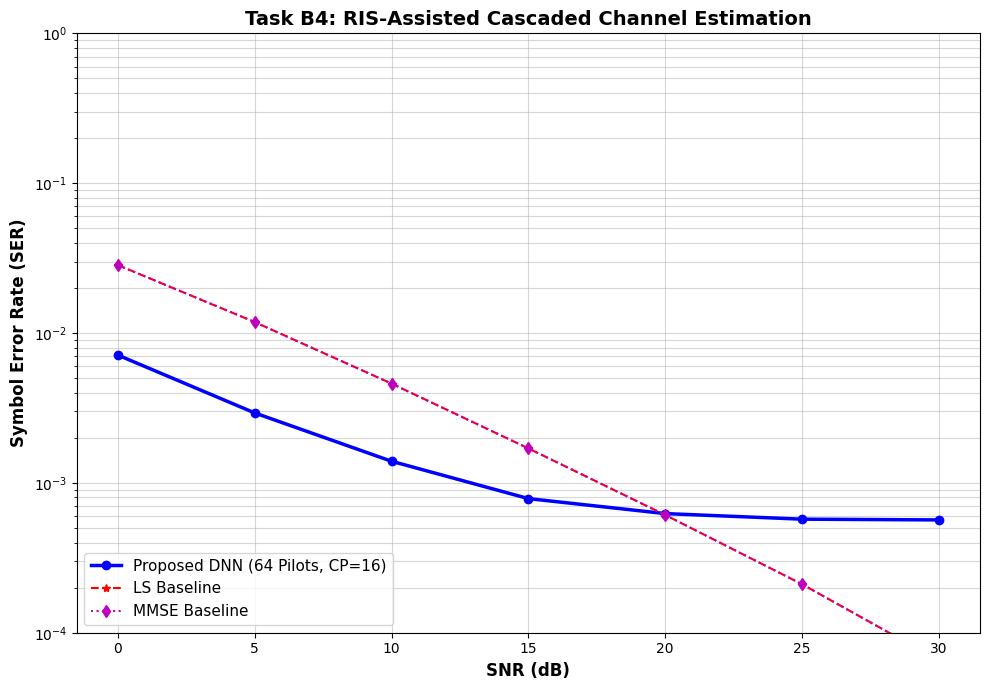

In [19]:
import torch
import torch.nn as nn
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


# ----------------------------
# Model Definition (MATCH TRAINING)
# ----------------------------
class RIS_DNN(nn.Module):
    def __init__(self, in_features=256, out_features=16):
        super().__init__()
        self.blocks = nn.ModuleList([
            nn.Linear(in_features, 500),
            nn.Linear(500, 250),
            nn.Linear(250, 120),
            nn.Linear(120, out_features)
        ])
        self.activations = [nn.ReLU(), nn.ReLU(), nn.ReLU(), nn.Identity()]

    def forward(self, x):
        for layer, act in zip(self.blocks, self.activations):
            x = act(layer(x))
        return x


# ----------------------------
# Setup
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Starting RIS DNN Inference on {device}...\n")


# ----------------------------
# Load Dataset
# ----------------------------
mat = sio.loadmat('/kaggle/input/datasets/nihitreddy/mlwc-assignment2-real1/RIS_Dataset.mat')

SNRs = mat['SNR_dB'][0]
SER_LS = mat['SER_LS'][0]          
SER_MMSE = mat['SER_MMSE'][0]      

Y_pilot_all = mat['DL_RIS_Y_pilot']
Y_data_all = mat['DL_RIS_Y_data']
X_symbols = mat['DL_RIS_X_data']

num_frames, num_snrs, _ = Y_pilot_all.shape


# ----------------------------
# Convert QPSK Symbols → Bits
# ----------------------------
bit0 = (np.real(X_symbols) > 0).astype(int)
bit1 = (np.imag(X_symbols) > 0).astype(int)
X_target_bits_full = np.concatenate((bit0, bit1), axis=-1)


# ----------------------------
# Load Models
# ----------------------------
num_chunks = 8
models = []

print("Loading trained models...")

for chunk_idx in range(num_chunks):
    model = RIS_DNN().to(device)
    model.load_state_dict(
        torch.load(f'/kaggle/working/RIS_model_part{chunk_idx}.pth', map_location=device)
    )
    model.eval()
    models.append(model)


# ----------------------------
# Load Scaler
# ----------------------------
scaler = np.load('/kaggle/working/scaler_RIS.npz')
Y_mean, Y_std = scaler['mean'], scaler['std']


# ----------------------------
# Inference
# ----------------------------
SER_DNN = np.zeros(num_snrs)

print("\nEvaluating SNRs...")

with torch.no_grad():
    for snr_idx in tqdm(range(num_snrs), desc="Inference Progress", unit="SNR"):

        Y_pilot = Y_pilot_all[:, snr_idx, :]
        Y_data = Y_data_all[:, snr_idx, :]
        
        # MATCH TRAINING EXACTLY
        Y_complex = np.concatenate((Y_pilot, Y_data), axis=-1)
        
        Y_input = np.concatenate((
            np.real(Y_complex),
            np.imag(Y_complex)
        ), axis=-1)
        
        Y_input_norm = (Y_input - Y_mean.reshape(1, -1)) / (Y_std.reshape(1, -1) + 1e-8)
        
        X_tensor = torch.FloatTensor(Y_input_norm).to(device)
        
        chunk_preds = [m(X_tensor).cpu().numpy() for m in models]
        
        final_outputs = np.concatenate(chunk_preds, axis=-1)
        
        predicted_bits = (final_outputs > 0).astype(int)
        
        errors = np.sum(predicted_bits != X_target_bits_full)
        
        SER_DNN[snr_idx] = errors / (num_frames * 128)


print(f"\n-> Final DNN SER at {SNRs[-1]} dB: {SER_DNN[-1]:.4e}")


# ----------------------------
# Plot Results (ALL 3 CURVES)
# ----------------------------
plt.figure(figsize=(10, 7))

plt.semilogy(SNRs, SER_DNN, 'b-o', label='Proposed DNN (64 Pilots, CP=16)', linewidth=2.5)
plt.semilogy(SNRs, SER_LS, 'r--*', label='LS Baseline', linewidth=1.5)
plt.semilogy(SNRs, SER_MMSE, 'm:d', label='MMSE Baseline', linewidth=1.5)

plt.grid(True, which="both", linestyle='-', alpha=0.5)
plt.xlabel('SNR (dB)', fontsize=12, fontweight='bold')
plt.ylabel('Symbol Error Rate (SER)', fontsize=12, fontweight='bold')
plt.title('Task B4: RIS-Assisted Cascaded Channel Estimation', fontsize=14, fontweight='bold')

plt.legend(loc='lower left', fontsize=11)
plt.ylim([1e-4, 1])

plt.tight_layout()
plt.show()